In [141]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap


In [142]:
lake=(0,0)
fire=[(4,4)]
smoke=[(1,2),(3,2)]
boulders=[(3,4),(2,4)]


In [143]:
def terminal(state):
    if tuple(state[1:3]) in fire and state[0]:
        return True
    elif tuple(state[1:3]) in boulders:
        return True 
    else:
        return False
    
def reward(state):
    pos = tuple(state[1:3])
    rew=-1
    if pos in fire and state[0]:
        return 100
    elif pos in smoke:
        rew-=10
    elif pos in boulders:
        return -100
    return rew

def movement(state, dirc):
    if state[1]==0 and state[2]==0:
        state=(1,0,0)
    if dirc=='N':
        if tuple(state[1:3])==(0,1) and not state[0]:
            return (1, 0,0)
        return state if state[2] == 0 else (state[0], state[1], state[2]-1)
    
    elif dirc=='S':
        return state if state[2] == 4 else (state[0], state[1], state[2]+1)
    
    elif dirc=='E':
        return state if state[1] == 4 else (state[0], state[1]+1, state[2])
    
    elif dirc=='W':
        if tuple(state[1:3])==(1,0) and not state[0]:
            return (1, 0,0)
        return state if state[1] == 0 else (state[0], state[1]-1, state[2])
    
    else:
        return state
    
def possible_states(state,dirc):
    if dirc == 'N':
        return [movement(state, 'N'), movement(state, 'E'), movement(state, 'W'),movement(state, '#')]
    elif dirc == 'S':
        return [movement(state, 'S'), movement(state, 'E'), movement(state, 'W'),movement(state, '#')]
    elif dirc == 'E':
        return [movement(state, 'E'), movement(state, 'N'), movement(state, 'S'),movement(state, '#')]
    elif dirc == 'W':
        return [movement(state, 'W'), movement(state, 'N'), movement(state, 'S'),movement(state, '#')]
    

In [144]:
def value_func( state, gamma, gridWorld):
    
    hover_val = reward(state) + gamma * gridWorld[state[0], state[1], state[2]]
    value =  hover_val
    
    if tuple(state[1:3]) in smoke:
        for dirc in ['N','S','E','W']:
            temp_val=0
            p_states = possible_states(state, dirc)
            p_state = p_states[0]
            temp_val += 0.4 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            p_state = p_states[3]
            temp_val += 0.4 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            for i in range(1,3):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
                    
    else:
        for dirc in ['N','S','E','W']:
            temp_val=0
            p_states = possible_states(state, dirc)

            p_state = p_states[0]
            temp_val += 0.7 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            
            for i in range(1,4):
                p_state = p_states[i]
                temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            value = max(value, temp_val)
        
    return value
        

In [145]:
def policy_iteration(gamma, theta):
    gridWorld=np.zeros((2,5,5), dtype=float)
    delta = float('inf')
    while delta > theta:

        for i in range(1,-1,-1):
            for j in range(4,-1,-1):
                for k in range(4,-1,-1):
                    state = [i,j,k]
                    if not terminal(state):
                        v = gridWorld[i,j,k]
                        gridWorld[i,j,k] = value_func(state, gamma, gridWorld)
                        delta = min(delta, abs(v - gridWorld[i,j,k]))

    return gridWorld
                    


In [146]:
def get_optimal_action(state, gamma, gridWorld):
    """
    Get the optimal action for a given state based on the value function.
    Returns the direction that maximizes expected value.
    """
    best_action = None
    best_value = -float('inf')
    
    directions = ['N', 'S', 'E', 'W', 'H']  # Added 'H' for hover action
    
    for dirc in directions:
        temp_val = 0
        
        if dirc == 'H':
            # Hover action: stay in place with 100% probability
            temp_val = reward(state) + gamma * gridWorld[state[0], state[1], state[2]]
        else:
            p_states = possible_states(state, dirc)
            
            # Skip this action if the intended direction results in staying in place (boundary)
            # This means the action is effectively hovering due to boundaries
            intended_state = tuple(p_states[0]) if isinstance(p_states[0], list) else p_states[0]
            if intended_state == tuple(state):
                continue
            
            # Check if state is in smoke (different probabilities)
            if tuple(state[1:3]) in smoke:
                temp_val += 0.4 * (reward(p_states[0]) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
                temp_val += 0.4 * (reward(p_states[3]) + gamma * gridWorld[p_states[3][0], p_states[3][1], p_states[3][2]])
                for i in range(1, 3):
                    p_state = p_states[i]
                    temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
            else:
                temp_val += 0.7 * (reward(p_states[0]) + gamma * gridWorld[p_states[0][0], p_states[0][1], p_states[0][2]])
                for i in range(1, 4):
                    p_state = p_states[i]
                    temp_val += 0.1 * (reward(p_state) + gamma * gridWorld[p_state[0], p_state[1], p_state[2]])
        
        if temp_val > best_value:
            best_value = temp_val
            best_action = dirc
    
    return best_action

def visualize_mdp(gridWorld, gamma=0.95):
    """
    Visualize both phases of the MDP with special regions highlighted and optimal policy arrows.
    
    Phase 0: Before picking up the key
    Phase 1: After picking up the key
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Define colors for special regions
    colors = {
        'lake': '#87CEEB',      # Sky blue
        'fire': '#FF4500',      # Orange red
        'smoke': '#708090',     # Slate gray
        'boulder': '#2F4F4F',   # Dark slate gray
        'normal': '#F5F5DC'     # Beige
    }
    
    for phase in range(2):
        ax = axes[phase]
        
        # Create a grid to color special regions
        color_grid = np.full((5, 5, 3), [0.96, 0.96, 0.86])  # Default beige color
        
        # Color special regions
        # Lake at (0,0)
        color_grid[0, 0] = [0.53, 0.81, 0.92]  # Sky blue
        
        # Fire at (4,4)
        color_grid[4, 4] = [1.0, 0.27, 0.0]  # Orange red
        
        # Smoke at (1,2) and (3,2)
        color_grid[2, 1] = [0.44, 0.50, 0.56]  # Slate gray
        color_grid[2, 3] = [0.44, 0.50, 0.56]  # Slate gray
        
        # Boulders at (3,4) and (2,4)
        color_grid[4, 3] = [0.18, 0.31, 0.31]  # Dark slate gray
        color_grid[4, 2] = [0.18, 0.31, 0.31]  # Dark slate gray
        
        # Display the grid
        ax.imshow(color_grid, extent=[0, 5, 0, 5], origin='lower', aspect='auto')
        
        # Add grid lines
        for i in range(6):
            ax.axhline(i, color='black', linewidth=1.5)
            ax.axvline(i, color='black', linewidth=1.5)
        
        # Add striped pattern to terminal states
        # Boulders at (2,4) and (3,4) - terminal in both phases
        for boulder_x in [2, 3]:
            rect = mpatches.Rectangle((boulder_x, 4), 1, 1, 
                                     linewidth=0, edgecolor='white', 
                                     facecolor='none', hatch='////', fill=False)
            ax.add_patch(rect)
        
        # Fire at (4,4) - terminal only in phase 1
        if phase == 1:
            rect = mpatches.Rectangle((4, 4), 1, 1, 
                                     linewidth=0, edgecolor='white', 
                                     facecolor='none', hatch='////', fill=False)
            ax.add_patch(rect)
        
        # Add value function text and policy arrows in each cell (skip terminal states)
        for i in range(5):
            for j in range(5):
                # Check if this is a terminal state
                is_terminal = False
                if (i, j) in [(2, 4), (3, 4)]:  # Boulders
                    is_terminal = True
                elif (i, j) == (4, 4) and phase == 1:  # Fire in phase 1
                    is_terminal = True
                
                if not is_terminal:
                    value = gridWorld[phase, i, j]
                    # Display value at the top of the cell
                    ax.text(i + 0.5, j + 0.75, f'{value:.1f}', 
                           ha='center', va='center', fontsize=9, fontweight='bold')
                    
                    # Get optimal action and draw arrow
                    state = [phase, i, j]
                    optimal_action = get_optimal_action(state, gamma, gridWorld)
                    
                    # Arrow parameters
                    arrow_length = 0.2
                    arrow_props = dict(arrowstyle='->', lw=2.5, color='darkblue')
                    
                    # Draw arrow or circle based on optimal action
                    # N decreases j (down), S increases j (up), E increases i (right), W decreases i (left)
                    if optimal_action == 'H':
                        # Draw a circle for hover/stay action
                        circle = plt.Circle((i + 0.5, j + 0.5), 0.15, color='red', fill=False, linewidth=2.5)
                        ax.add_patch(circle)
                    elif optimal_action == 'N':
                        ax.annotate('', xy=(i + 0.5, j + 0.5 - arrow_length), 
                                   xytext=(i + 0.5, j + 0.5 + arrow_length),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'S':
                        ax.annotate('', xy=(i + 0.5, j + 0.5 + arrow_length), 
                                   xytext=(i + 0.5, j + 0.5 - arrow_length),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'E':
                        ax.annotate('', xy=(i + 0.5 + arrow_length, j + 0.5), 
                                   xytext=(i + 0.5 - arrow_length, j + 0.5),
                                   arrowprops=arrow_props)
                    elif optimal_action == 'W':
                        ax.annotate('', xy=(i + 0.5 - arrow_length, j + 0.5), 
                                   xytext=(i + 0.5 + arrow_length, j + 0.5),
                                   arrowprops=arrow_props)
        
        # Set labels and title
        ax.set_xlim(0, 5)
        ax.set_ylim(0, 5)
        ax.set_xticks(np.arange(0.5, 5.5, 1))
        ax.set_yticks(np.arange(0.5, 5.5, 1))
        ax.set_xticklabels(range(5))
        ax.set_yticklabels(range(5))
        ax.set_xlabel('X coordinate', fontsize=12)
        ax.set_ylabel('Y coordinate', fontsize=12)
        
        if phase == 0:
            ax.set_title('Phase 0: Before Picking Up Water', fontsize=14, fontweight='bold')
        else:
            ax.set_title('Phase 1: After Picking Up Water', fontsize=14, fontweight='bold')
        
        ax.grid(False)
    
    # Create legend
    legend_elements = [
        mpatches.Patch(facecolor='#87CEEB', edgecolor='black', label='Lake (0,0)'),
        mpatches.Patch(facecolor='#FF4500', edgecolor='black', label='Fire (4,4) - Terminal in Phase 1'),
        mpatches.Patch(facecolor='#708090', edgecolor='black', label='Smoke (1,2), (3,2)'),
        mpatches.Patch(facecolor='#2F4F4F', edgecolor='black', label='Boulders (3,4), (2,4) - Terminal'),
        mpatches.Patch(facecolor='#F5F5DC', edgecolor='black', label='Normal cells'),
        mpatches.Patch(facecolor='none', edgecolor='red', label='Red Circle = Hover Action')
    ]
    
    fig.legend(handles=legend_elements, loc='lower center', ncol=6, 
              bbox_to_anchor=(0.5, -0.05), fontsize=10, frameon=True)
    
    # Add overall title
    fig.suptitle(f'Optimal Policy for Gamma={gamma})', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, top=0.88)
    plt.show()




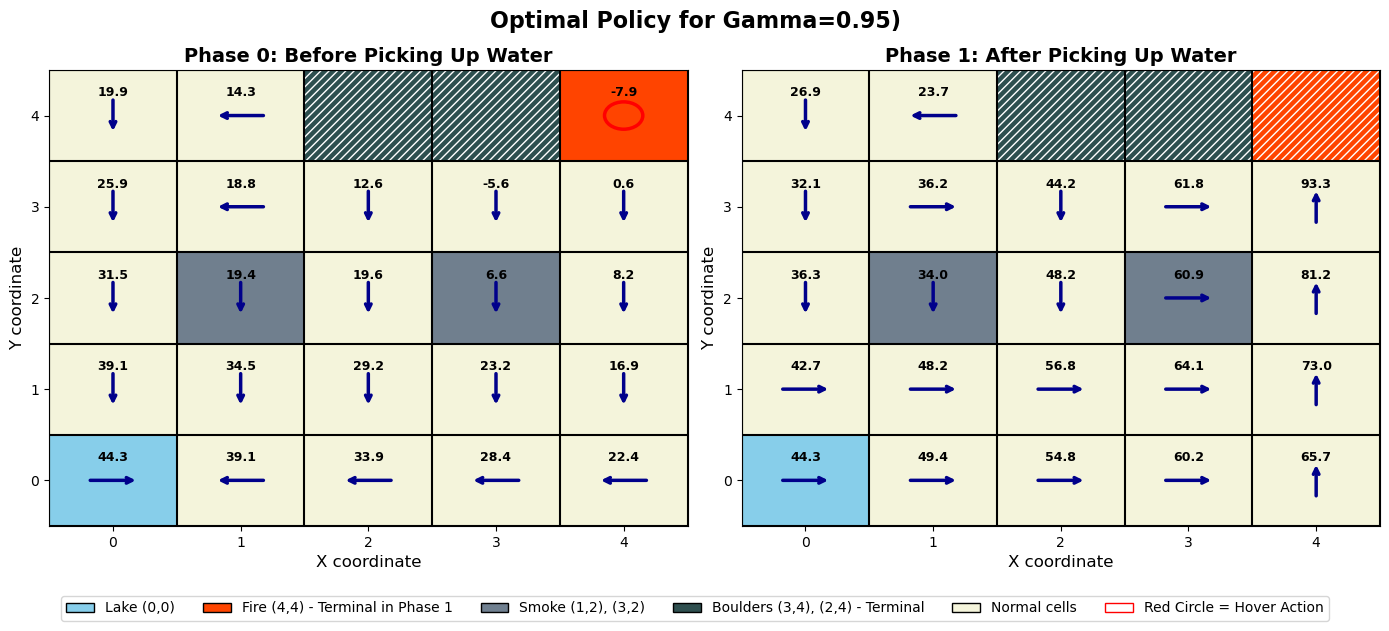

In [147]:
gridWorld=policy_iteration(0.95, 0.01)
visualize_mdp(gridWorld, gamma=0.95)



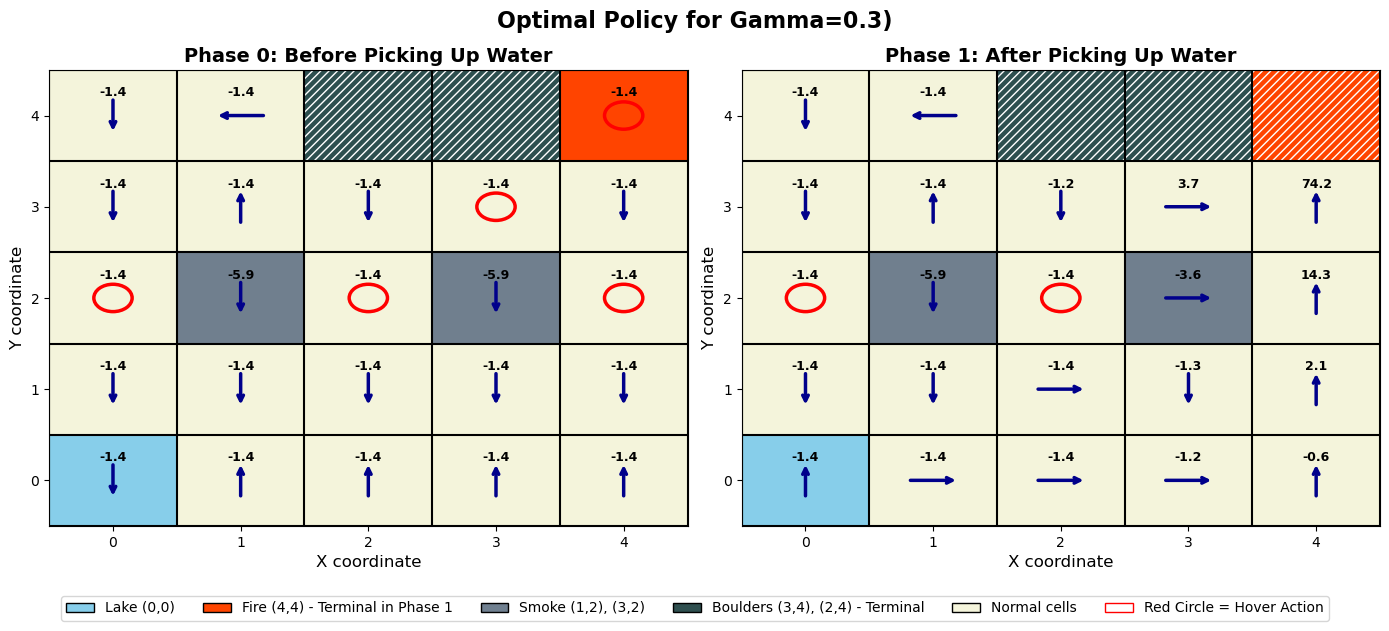

In [148]:
gridWorld_alt_Gamma=policy_iteration(0.3, 0.01)
visualize_mdp(gridWorld_alt_Gamma, gamma=0.3)